Koden läser CSV-fil med personaldata. Därefter städas datan genom att omvandla eventuella textkategorier till numeriska värden så att algoritmen kan förstå dem, och målvariabeln, som anger om personen slutat eller stannate, separeras från de övriga egenskaperna. Materialet delas sedan upp i en träningsmängd och en testmängd, varpå en Random Forest-modell tränas på den större delen för att hitta underliggande mönster kring varför anställda lämnar företaget. Avslutningsvis sätts modellen på prov mot den osedda testdatan. Resultaten från detta test presenteras sedan i form av övergripande träffsäkerhet, en detaljerad utvärderingsrapport och en visuell förvirringsmatris som tydligt illustrerar hur många korrekta och felaktiga gissningar modellen gjorde för respektive svarsalternativ.

--- Resultat från Random Forest-modellen ---

Accuracy (Andel rätta gissningar totalt): 0.97

Detaljerad rapport (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      2294
           1       0.98      0.91      0.94       706

    accuracy                           0.97      3000
   macro avg       0.98      0.95      0.96      3000
weighted avg       0.98      0.97      0.97      3000


 Confusion Matrix


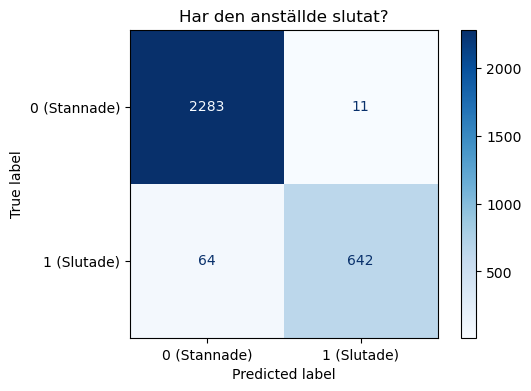

In [11]:
# Säg åt Jupyter att visa eventuella grafer direkt i output-fältet
%matplotlib inline

# Importera nödvändiga bibliotek
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Ladda datan
# ---------------------------------------------------------
file_name = 'hr_employee_data.xlsx'
df = pd.read_excel(file_name)

# ---------------------------------------------------------
# 2. Förbered datan (Preprocessing)
# ---------------------------------------------------------
# Maskininlärningsmodeller vill ha siffror. Om datasetet innehåller text
# (t.ex. avdelning eller lönenivå) gör vi om dem till så kallade dummy-variabler.
df_encoded = pd.get_dummies(df, drop_first=True)

# Separera vår målvariabel (y) från resten av datan (X)
X = df_encoded.drop('left', axis=1)
y = df_encoded['left']

# ---------------------------------------------------------
# 3. Dela upp datan i Träning och Test
# ---------------------------------------------------------
# Vi sparar 20% av datan för att testa modellen, och tränar på 80%.
# random_state=42 gör att vi får samma uppdelning varje gång koden körs.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 4. Skapa och Träna modellen
# ---------------------------------------------------------
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. Utvärdera modellen
# ---------------------------------------------------------
# Låt modellen gissa på testdatan
y_pred = model.predict(X_test)

# Skriv ut resultaten
print("--- Resultat från Random Forest-modellen ---\n")
print(f"Accuracy (Andel rätta gissningar totalt): {accuracy_score(y_test, y_pred):.2f}\n")
print("Detaljerad rapport (Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred))

# Visualisera resultatet med en Confusion Matrix
print("\n Confusion Matrix")
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test, 
    display_labels=['0 (Stannade)', '1 (Slutade)'], 
    cmap='Blues', 
    ax=ax
)
plt.title('Har den anställde slutat?')
plt.show()

denna Random Forest-modell presterar utmärkt och är ett mycket tillförlitligt verktyg för att förutsäga personalomsättning. Övergripande gissar modellen rätt i hela 97 procent av alla fall, vilket innebär att den har klassificerat 2925 av 3000 testade anställda helt korrekt. När det gäller personal som stannar är den i princip felfri; av 2294 personer identifierade den 2283 rätt och gav ett falskt alarm för endast 11 personer.
När det kommer till att identifiera de som faktiskt är på väg att sluta är modellen också mycket skarp. Precisionen ligger på 98 procent, vilket betyder att när verktyget väl varnar för ett avhopp, har det rätt i nästan alla fall. Samtidigt ligger upptäckandegraden (recall) på 91 procent, vilket innebär att den framgångsrikt ringade in 642 av de 706 personer som i verkligheten slutade. Även om den missade 64 personer som försvann under radarn, innebär den höga träffsäkerheten i larmen att modellen är ett extremt starkt beslutsstöd. HR och ledning kan därför med stor trygghet luta sig mot dessa insikter för att i god tid agera och behålla värdefull personal.